c:\Users\Acer\dudee-venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Epoch [10/100], Loss: 0.0217
Epoch [20/100], Loss: 0.0151
Epoch [30/100], Loss: 0.0089
Epoch [40/100], Loss: 0.0050
Epoch [50/100], Loss: 0.0029
Epoch [60/100], Loss: 0.0017
Epoch [70/100], Loss: 0.0011
Epoch [80/100], Loss: 0.0008
Epoch [90/100], Loss: 0.0006
Epoch [100/100], Loss: 0.0004


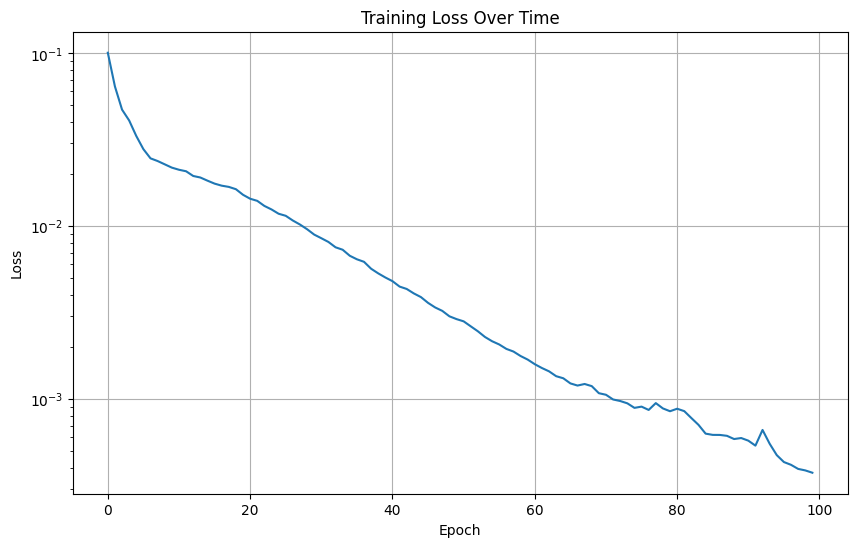


Parameter Estimation Results:
True Parameters (μ, σ) vs Predicted Parameters:
True: (-0.4819, 0.1167) Predicted: (-0.4361, 0.1419)
True: (0.4759, 0.4484) Predicted: (0.4888, 0.4538)
True: (-0.3483, 0.2818) Predicted: (-0.3572, 0.2546)
True: (-0.0882, 0.2839) Predicted: (-0.0956, 0.2913)
True: (-0.0683, 0.1351) Predicted: (-0.0639, 0.1750)


In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

class GBMDataset(Dataset):
    def __init__(self, num_samples=1000, seq_length=252, dt=1/252):
        self.num_samples = num_samples
        self.seq_length = seq_length
        self.dt = dt
        
        # Generate random parameters for GBM
        self.mu = np.random.uniform(-0.5, 0.5, num_samples)  # drift
        self.sigma = np.random.uniform(0.1, 0.5, num_samples)  # volatility
        
        # Generate price paths
        self.paths = self._generate_paths()
        
        # Calculate log returns
        self.log_returns = np.diff(np.log(self.paths), axis=1)
    
    def _generate_paths(self):
        paths = np.zeros((self.num_samples, self.seq_length))
        S0 = 100  # Initial price
        
        for i in range(self.num_samples):
            # Generate Brownian motion increments
            dW = np.random.normal(0, np.sqrt(self.dt), self.seq_length-1)
            
            # Calculate price path
            paths[i, 0] = S0
            for t in range(1, self.seq_length):
                paths[i, t] = paths[i, t-1] * np.exp(
                    (self.mu[i] - 0.5 * self.sigma[i]**2) * self.dt + 
                    self.sigma[i] * dW[t-1]
                )
        
        return paths
    
    def __len__(self):
        return self.num_samples
    
    def __getitem__(self, idx):
        log_returns = self.log_returns[idx]
        params = np.array([self.mu[idx], self.sigma[idx]])
        return torch.FloatTensor(log_returns), torch.FloatTensor(params)

class MLPEstimator(nn.Module):
    def __init__(self, input_size, hidden_size=64):
        super(MLPEstimator, self).__init__()
        
        self.network = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 2)  # Output: [mu, sigma]
        )
        
        # Custom activation for sigma to ensure positivity
        self.sigma_activation = nn.Softplus()
    
    def forward(self, x):
        output = self.network(x)
        mu = output[:, 0]  # First output is mu
        sigma = self.sigma_activation(output[:, 1])  # Second output is sigma (must be positive)
        return torch.stack([mu, sigma], dim=1)

def train_model(model, train_loader, num_epochs=100, learning_rate=0.001):
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.MSELoss()
    
    train_losses = []
    
    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0
        
        for batch_idx, (log_returns, true_params) in enumerate(train_loader):
            optimizer.zero_grad()
            
            # Forward pass
            predicted_params = model(log_returns)
            
            # Compute loss
            loss = criterion(predicted_params, true_params)
            
            # Backward pass and optimize
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
        
        avg_epoch_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_epoch_loss)
        
        if (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_epoch_loss:.4f}')
    
    return train_losses

def main():
    # Set random seed for reproducibility
    torch.manual_seed(42)
    np.random.seed(42)
    
    # Create dataset
    dataset = GBMDataset(num_samples=1000)
    train_loader = DataLoader(dataset, batch_size=32, shuffle=True)
    
    # Initialize model
    seq_length = 251  # number of log returns (one less than price points)
    model = MLPEstimator(input_size=seq_length)
    
    # Train model
    train_losses = train_model(model, train_loader)
    
    # Plot training loss
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Loss Over Time')
    plt.yscale('log')
    plt.grid(True)
    plt.show()
    
    # Evaluate on a few examples
    model.eval()
    test_loader = DataLoader(dataset, batch_size=5, shuffle=True)
    log_returns, true_params = next(iter(test_loader))
    
    with torch.no_grad():
        predicted_params = model(log_returns)
    
    print("\nParameter Estimation Results:")
    print("True Parameters (μ, σ) vs Predicted Parameters:")
    for i in range(5):
        print(f"True: ({true_params[i,0]:.4f}, {true_params[i,1]:.4f}) "
              f"Predicted: ({predicted_params[i,0]:.4f}, {predicted_params[i,1]:.4f})")

if __name__ == "__main__":
    main()

[*********************100%***********************]  1 of 1 completed


Epoch [10/100], Loss: 0.0401
Validation Loss: 0.0176
Epoch [20/100], Loss: 0.0259
Validation Loss: 0.0127
Epoch [30/100], Loss: 0.0191
Validation Loss: 0.0108
Epoch [40/100], Loss: 0.0164
Validation Loss: 0.0093
Epoch [50/100], Loss: 0.0148
Validation Loss: 0.0082
Epoch [60/100], Loss: 0.0144
Validation Loss: 0.0074
Epoch [70/100], Loss: 0.0132
Validation Loss: 0.0069
Epoch [80/100], Loss: 0.0135
Validation Loss: 0.0065
Epoch [90/100], Loss: 0.0129
Validation Loss: 0.0065
Epoch [100/100], Loss: 0.0131
Validation Loss: 0.0067


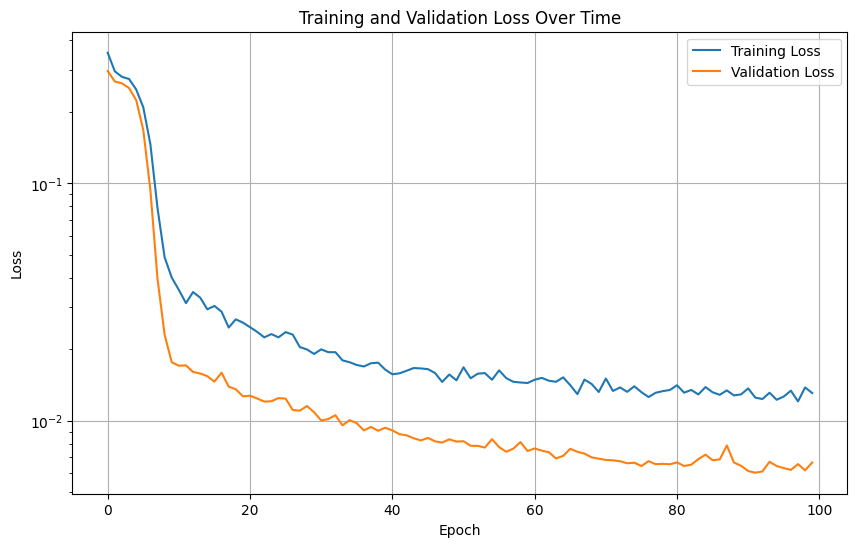


Parameter Estimation Results:
True Parameters (μ, σ) vs Predicted Parameters:
True: (0.4973, 0.1896) Predicted: (0.5015, 0.2561)
True: (-0.5114, 0.3084) Predicted: (-0.4318, 0.3190)
True: (0.5200, 0.1665) Predicted: (0.5227, 0.2524)
True: (0.3147, 0.3051) Predicted: (0.3292, 0.2546)
True: (0.5512, 0.1974) Predicted: (0.5545, 0.2570)


In [36]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from datetime import datetime
import matplotlib.pyplot as plt
import yfinance as yf
data = yf.download("GOOG", start="2019-01-01", end="2024-12-01")

class StockDataset(Dataset):
    def __init__(self, data, window_size=60):
        # Read the data
        self.df = data
        # self.df['date'] = pd.to_datetime(self.df['date'])
        self.df = self.df.sort_values('date')
        
        # Calculate log returns
        self.df['log_return'] = np.log(self.df['close'] / self.df['close'].shift(1))
        self.df = self.df.dropna()
        
        # Calculate rolling windows
        self.window_size = window_size
        self.windows = []
        self.realized_params = []
        
        for i in range(len(self.df) - window_size):
            window = self.df['log_return'].iloc[i:i+window_size].values
            self.windows.append(window)
            
            # Calculate realized parameters for this window
            mu = np.mean(window) * 252  # Annualized drift
            sigma = np.std(window) * np.sqrt(252)  # Annualized volatility
            self.realized_params.append([mu, sigma])
    
    def __len__(self):
        return len(self.windows)
    
    def __getitem__(self, idx):
        return (torch.FloatTensor(self.windows[idx]), 
                torch.FloatTensor(self.realized_params[idx]))

class MLPEstimator(nn.Module):
    def __init__(self, input_size, hidden_size=64):
        super(MLPEstimator, self).__init__()
        
        self.network = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(0.2),  # Added dropout for regularization
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_size, 2)  # Output: [mu, sigma]
        )
        
        # Custom activation for sigma to ensure positivity
        self.sigma_activation = nn.Softplus()
    
    def forward(self, x):
        output = self.network(x)
        mu = output[:, 0]  # First output is mu
        sigma = self.sigma_activation(output[:, 1])  # Second output is sigma (must be positive)
        return torch.stack([mu, sigma], dim=1)

def train_model(model, train_loader, val_loader=None, num_epochs=100, learning_rate=0.001):
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.MSELoss()
    
    train_losses = []
    val_losses = []
    
    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0
        
        for batch_idx, (log_returns, true_params) in enumerate(train_loader):
            optimizer.zero_grad()
            
            # Forward pass
            predicted_params = model(log_returns)
            
            # Compute loss
            loss = criterion(predicted_params, true_params)
            
            # Backward pass and optimize
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
        
        avg_epoch_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_epoch_loss)
        
        # Validation step
        if val_loader is not None:
            model.eval()
            val_loss = 0
            with torch.no_grad():
                for log_returns, true_params in val_loader:
                    predicted_params = model(log_returns)
                    val_loss += criterion(predicted_params, true_params).item()
            val_losses.append(val_loss / len(val_loader))
        
        if (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_epoch_loss:.4f}')
            if val_loader is not None:
                print(f'Validation Loss: {val_losses[-1]:.4f}')
    
    return train_losses, val_losses

def plot_results(train_losses, val_losses=None):
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label='Training Loss')
    if val_losses:
        plt.plot(val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss Over Time')
    plt.yscale('log')
    plt.legend()
    plt.grid(True)
    plt.show()

def main():
    # Set random seed for reproducibility
    torch.manual_seed(42)
    np.random.seed(42)
    df = data.copy()
    prices = df["Close"].values.reshape(-1)
    dates = data.index
    df = pd.DataFrame(data={"date":dates,"close":prices})
    # Create dataset
    dataset = StockDataset(df, window_size=30)

    # Split into train and validation sets
    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

    # Initialize model
    model = MLPEstimator(input_size=30)

    # Train model
    train_losses, val_losses = train_model(model, train_loader, val_loader)

    # Plot results
    plot_results(train_losses, val_losses)

    # Evaluate on a few examples
    model.eval()
    test_loader = DataLoader(val_dataset, batch_size=5, shuffle=True)
    log_returns, true_params = next(iter(test_loader))

    with torch.no_grad():
        predicted_params = model(log_returns)

    print("\nParameter Estimation Results:")
    print("True Parameters (μ, σ) vs Predicted Parameters:")
    for i in range(5):
        print(f"True: ({true_params[i,0]:.4f}, {true_params[i,1]:.4f}) "
                f"Predicted: ({predicted_params[i,0]:.4f}, {predicted_params[i,1]:.4f})")

if __name__ == "__main__":
    main()

[*********************100%***********************]  1 of 1 completed


Epoch [10/100], Loss: 0.0224
Validation Loss: 0.0174
Epoch [20/100], Loss: 0.0080
Validation Loss: 0.0035
Epoch [30/100], Loss: 0.0069
Validation Loss: 0.0034
Epoch [40/100], Loss: 0.0058
Validation Loss: 0.0034
Epoch [50/100], Loss: 0.0056
Validation Loss: 0.0032
Epoch [60/100], Loss: 0.0053
Validation Loss: 0.0032
Epoch [70/100], Loss: 0.0052
Validation Loss: 0.0031
Epoch [80/100], Loss: 0.0049
Validation Loss: 0.0035
Epoch [90/100], Loss: 0.0047
Validation Loss: 0.0030
Epoch [100/100], Loss: 0.0043
Validation Loss: 0.0029


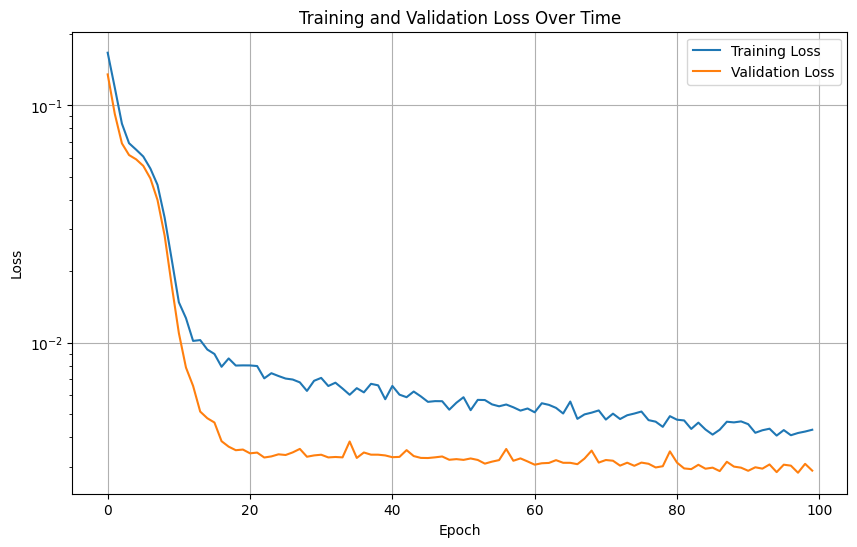


Parameter Estimation Results:
True Parameters (μ, σ) vs Predicted Parameters:
True: (0.5141, 0.2710) Predicted: (0.4990, 0.2803)
True: (-0.4696, 0.4020) Predicted: (-0.3796, 0.3385)
True: (-0.5247, 0.3705) Predicted: (-0.4686, 0.3675)
True: (-0.2336, 0.4120) Predicted: (-0.2311, 0.3384)
True: (0.7448, 0.2364) Predicted: (0.7061, 0.2329)


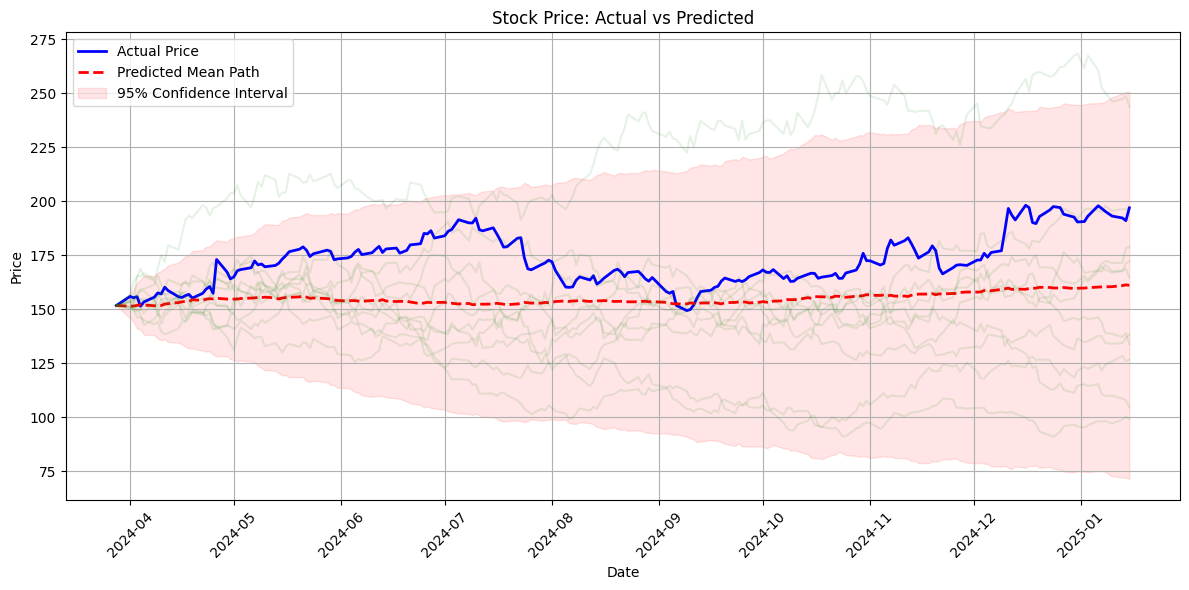

Estimated Parameters:
μ (drift): 0.0499
σ (volatility): 0.3246


In [47]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import yfinance as yf
data = yf.download("GOOG", start="2019-01-01", end="2025-01-16")

class StockDataset(Dataset):
    def __init__(self, data, window_size=60):
        # Read the data
        self.df = data
        # self.df['date'] = pd.to_datetime(self.df['date'])
        self.df = self.df.sort_values('date')
        
        # Calculate log returns
        self.df['log_return'] = np.log(self.df['close'] / self.df['close'].shift(1))
        self.df = self.df.dropna()
        
        # Calculate rolling windows
        self.window_size = window_size
        self.windows = []
        self.realized_params = []
        
        for i in range(len(self.df) - window_size):
            window = self.df['log_return'].iloc[i:i+window_size].values
            self.windows.append(window)
            
            # Calculate realized parameters for this window
            mu = np.mean(window) * 252  # Annualized drift
            sigma = np.std(window) * np.sqrt(252)  # Annualized volatility
            self.realized_params.append([mu, sigma])
    
    def __len__(self):
        return len(self.windows)
    
    def __getitem__(self, idx):
        return (torch.FloatTensor(self.windows[idx]), 
                torch.FloatTensor(self.realized_params[idx]))

class MLPEstimator(nn.Module):
    def __init__(self, input_size, hidden_size=64):
        super(MLPEstimator, self).__init__()
        
        self.network = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(0.2),  # Added dropout for regularization
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_size, 2)  # Output: [mu, sigma]
        )
        
        # Custom activation for sigma to ensure positivity
        self.sigma_activation = nn.Softplus()
    
    def forward(self, x):
        output = self.network(x)
        mu = output[:, 0]  # First output is mu
        sigma = self.sigma_activation(output[:, 1])  # Second output is sigma (must be positive)
        return torch.stack([mu, sigma], dim=1)

def train_model(model, train_loader, val_loader=None, num_epochs=100, learning_rate=0.001):
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.MSELoss()
    
    train_losses = []
    val_losses = []
    
    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0
        
        for batch_idx, (log_returns, true_params) in enumerate(train_loader):
            optimizer.zero_grad()
            
            # Forward pass
            predicted_params = model(log_returns)
            
            # Compute loss
            loss = criterion(predicted_params, true_params)
            
            # Backward pass and optimize
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
        
        avg_epoch_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_epoch_loss)
        
        # Validation step
        if val_loader is not None:
            model.eval()
            val_loss = 0
            with torch.no_grad():
                for log_returns, true_params in val_loader:
                    predicted_params = model(log_returns)
                    val_loss += criterion(predicted_params, true_params).item()
            val_losses.append(val_loss / len(val_loader))
        
        if (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_epoch_loss:.4f}')
            if val_loader is not None:
                print(f'Validation Loss: {val_losses[-1]:.4f}')
    
    return train_losses, val_losses

def plot_results(train_losses, val_losses=None):
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label='Training Loss')
    if val_losses:
        plt.plot(val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss Over Time')
    plt.yscale('log')
    plt.legend()
    plt.grid(True)
    plt.show()

def simulate_gbm_paths(S0, mu, sigma, T, N, num_paths=100):
    """
    Simulate GBM paths using estimated parameters
    S0: initial stock price
    mu: drift
    sigma: volatility
    T: time horizon in years
    N: number of time steps
    num_paths: number of simulation paths
    """
    dt = T/N
    paths = np.zeros((num_paths, N+1))
    paths[:, 0] = S0
    
    for t in range(1, N+1):
        dW = np.random.normal(0, np.sqrt(dt), num_paths)
        paths[:, t] = paths[:, t-1] * np.exp((mu - 0.5 * sigma**2) * dt + sigma * dW)
    
    return paths

def plot_price_comparison(model, dataset, prediction_window=30):
    """
    Plot actual prices vs predicted price paths
    """
    model.eval()
    
    # Get the last window of data
    last_returns = dataset.windows[-1]
    last_params = dataset.realized_params[-1]
    
    # Get model prediction
    with torch.no_grad():
        predicted_params = model(torch.FloatTensor(last_returns).unsqueeze(0))
    
    mu_pred = predicted_params[0, 0].item()
    sigma_pred = predicted_params[0, 1].item()
    
    # Get actual prices for comparison
    actual_prices = dataset.df['close'].values[-prediction_window-1:]
    dates = dataset.df['date'].values[-prediction_window-1:]
    
    # Simulate future paths
    S0 = actual_prices[0]
    T = prediction_window/252  # Convert days to years
    paths = simulate_gbm_paths(S0, mu_pred, sigma_pred, T, prediction_window, num_paths=100)
    
    # Calculate confidence intervals
    mean_path = np.mean(paths, axis=0)
    std_path = np.std(paths, axis=0)
    
    # Plot results
    plt.figure(figsize=(12, 6))
    
    # Plot actual prices
    plt.plot(dates, actual_prices, 'b-', label='Actual Price', linewidth=2)
    
    # Plot predicted mean path
    plt.plot(dates, mean_path, 'r--', label='Predicted Mean Path', linewidth=2)
    
    # Plot confidence intervals
    plt.fill_between(dates, 
                    mean_path - 2*std_path, 
                    mean_path + 2*std_path,
                    color='r', alpha=0.1, label='95% Confidence Interval')
    
    # Plot some sample paths
    for i in range(min(10, paths.shape[0])):
        plt.plot(dates, paths[i], 'g-', alpha=0.1)
    
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.title('Stock Price: Actual vs Predicted')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    print(f"Estimated Parameters:")
    print(f"μ (drift): {mu_pred:.4f}")
    print(f"σ (volatility): {sigma_pred:.4f}")

def main():
    # Set random seed for reproducibility
    torch.manual_seed(42)
    np.random.seed(42)
    
    df = data.copy()
    prices = df["Close"].values.reshape(-1)
    dates = data.index
    df = pd.DataFrame(data={"date":dates,"close":prices})
    # Create dataset
    dataset = StockDataset(df, window_size=128)
    
    # Split into train and validation sets
    train_size = int(0.5 * len(dataset))
    val_size = len(dataset) - train_size
    train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])
    
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
    
    # Initialize model
    model = MLPEstimator(input_size=128)
    
    # Train model
    train_losses, val_losses = train_model(model, train_loader, val_loader)
    
    # Plot results
    plot_results(train_losses, val_losses)
    
    # Evaluate on a few examples
    model.eval()
    test_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
    log_returns, true_params = next(iter(test_loader))
    
    with torch.no_grad():
        predicted_params = model(log_returns)
    
    print("\nParameter Estimation Results:")
    print("True Parameters (μ, σ) vs Predicted Parameters:")
    for i in range(5):
        print(f"True: ({true_params[i,0]:.4f}, {true_params[i,1]:.4f}) "
              f"Predicted: ({predicted_params[i,0]:.4f}, {predicted_params[i,1]:.4f})")
    
    # Plot price comparison
    plot_price_comparison(model, dataset, prediction_window=200)

if __name__ == "__main__":
    main()